[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kuffmode/OHBM-Example-2026/blob/main/Reservoir_Tutorials/experiment_1_rc_random_mc.ipynb)

# Experiment 1: Memory Capacity of an Echo State Network — Random Parameters

In this experiment we evaluate the **Memory Capacity (MC)** of an Echo State Network (ESN) whose parameters are chosen *without any tuning*. The goal is to establish a baseline and build intuition for what the task measures, before we ask: *how much does parameter choice matter?*

---

### What is the Memory Capacity task?

We feed the reservoir a scalar i.i.d. Gaussian signal $u(t)$ and ask it to simultaneously reconstruct $K$ delayed versions of that signal:

$$\hat{y}_k(t) \approx u(t - k), \quad k = 1, 2, \ldots, K$$

The **total Memory Capacity** is the sum of squared Pearson correlations between the true delayed signal and the reservoir's reconstruction across all lags:

$$\text{MC} = \sum_{k=1}^{K} r^2\!\left(u(t-k),\; \hat{y}_k(t)\right)$$

**Theoretical bounds:**
- A reservoir with *no memory at all* (e.g. random i.i.d. states) would score MC ≈ 0.
- A linear reservoir of size $N$ has a theoretical upper bound of MC ≤ $N$.
- In practice, nonlinearity and finite data reduce this. A well-tuned ESN with $N=400$ typically reaches MC ≈ 40–55.


---

### A note on transients

The ESN reservoir starts from a **zero initial state** both at the beginning of training and at the beginning of testing. It takes several time steps for the reservoir dynamics to "synchronize" with the input signal. During this *transient* period the reservoir states (and therefore predictions) are unreliable.

We therefore discard the first `N_TRANSIENT` steps in **both** the training and test phases before computing MC or plotting results. Failing to do this — especially on the test side, which `echoes` does not handle automatically — would artificially deflate performance.

## 0 · Setup

In [1]:
# Run this cell once on Colab to install the echoes library
!pip install echoes --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 1.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from echoes import ESNRegressor

rng_global = np.random.default_rng(42)   # for reproducible neuron selection in plots
print('All imports OK.')

All imports OK.


## 1 · Hyperparameters

All parameters below are **fixed for this experiment** — nothing is tuned.  
The reservoir weights and input weights are drawn randomly; `random_state` controls the reservoir weight matrix, while `W_in` is constructed explicitly so we can store it for plotting.

In [3]:
# ── Data
SEQ_LEN       = 3000   # total length of the input sequence
TRAIN_FRAC    = 0.7    # fraction used for training
NUM_DELAYS    = 40     # number of lags to reconstruct (= number of outputs)

# ── Reservoir
N_RESERVOIR   = 100    # number of reservoir neurons
SPECTRAL_RAD  = 0.9    # spectral radius of the recurrent weight matrix
SPARSITY      = 0.9    # fraction of recurrent connections set to zero
INPUT_SCALING = 0.5    # scaling of the input weight matrix
BIAS          = 0.5    # constant bias injected to all neurons at every step

# ── Transient
N_TRANSIENT   = 100    # steps discarded at the start of both train and test phases

# ── Experiment
N_TRIALS      = 5      # independent trials (different random seeds)
PLOT_TRIAL    = 0      # which trial to visualise (0-indexed)
PLOT_LAG      = 5      # which lag to show in the signal reconstruction panel
N_NEURONS_PLOT = 10   # number of randomly chosen neurons to display
PLOT_WINDOW   = 200    # number of test time-steps shown in the signal/neuron panels

## 2 · Data generation

In [4]:
def generate_mc_data(seq_len, num_delays, seed=None):
    """Generate i.i.d. Gaussian input and its causal lagged targets.

    Returns
    -------
    X : ndarray (seq_len, 1)            — input signal
    y : ndarray (seq_len, num_delays)   — targets y[:,k] = u[t - (k+1)]
    """
    rng = np.random.default_rng(seed)
    u   = rng.standard_normal(seq_len)

    y = np.zeros((seq_len, num_delays))
    for k in range(num_delays):           # lag k+1
        y[k + 1:, k] = u[:seq_len - k - 1]

    return u.reshape(-1, 1), y

## 3 · Memory Capacity metric

For each lag $k$ we compute the squared Pearson correlation between the true delayed signal and the reservoir's prediction. The total MC is their sum.

In [5]:
def memory_capacity(y_true, y_pred):
    """Total MC as sum of squared Pearson r across lag dimensions.

    Parameters
    ----------
    y_true, y_pred : ndarray (n_samples, num_delays)
        Must already have the transient removed before calling.

    Returns
    -------
    mc          : float   — total memory capacity
    r2_per_lag  : ndarray — squared Pearson r for each individual lag
    """
    r2_per_lag = np.array([
        pearsonr(y_true[:, k], y_pred[:, k])[0] ** 2
        for k in range(y_true.shape[1])
    ])
    return float(r2_per_lag.sum()), r2_per_lag

## 4 · Single-trial ESN training and evaluation

In [6]:
def run_trial(seed, store_states=False):
    """Run one trial: generate data, train ESN, evaluate MC.

    Parameters
    ----------
    seed         : int   — controls both data generation and reservoir weights
    store_states : bool  — if True, reservoir neuron traces are stored

    Returns
    -------
    result : dict with keys
        train_mc, test_mc          — scalar MC scores
        train_r2, test_r2          — per-lag squared Pearson r arrays
        y_train, y_pred_train      — training targets / predictions (post-transient)
        y_test,  y_pred_test       — test targets / predictions (post-transient)
        X_test                     — test input signal (post-transient)
        esn                        — fitted ESNRegressor object
        W_in                       — input weight matrix used
    """
    # ── Data
    X, y = generate_mc_data(SEQ_LEN, NUM_DELAYS, seed=seed)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=TRAIN_FRAC, shuffle=False
    )

    # ── Build W_in explicitly so we can inspect it later
    # echoes expects W_in of shape (n_reservoir, 1 + n_inputs); the extra
    # column is for the bias term which echoes appends internally.
    rng_win = np.random.default_rng(seed)
    W_in = rng_win.uniform(-1.0, 1.0, size=(N_RESERVOIR, 1)) * INPUT_SCALING

    # ── ESN
    esn = ESNRegressor(
        n_reservoir        = N_RESERVOIR,
        spectral_radius    = SPECTRAL_RAD,
        sparsity           = SPARSITY,
        W_in               = W_in,
        input_scaling      = None,        # already absorbed into W_in
        bias               = BIAS,
        noise              = 0.0,
        fit_only_states    = True,
        n_transient        = N_TRANSIENT,
        regression_method  = 'pinv',
        random_state       = seed,
        store_states_train = store_states,
        store_states_pred  = store_states,
    )

    esn.fit(X_train, y_train)
    y_pred_test = esn.predict(X_test)

    # ── Discard transient from BOTH phases before scoring
    # Training: echoes already excludes n_transient from W_out fitting,
    #           but training_prediction_ covers the full sequence — we slice.
    # Test:     echoes reinitialises states to zero, so we must slice manually.
    t = N_TRANSIENT

    train_mc, train_r2 = memory_capacity(y_train[t:], esn.training_prediction_[t:])
    test_mc,  test_r2  = memory_capacity(y_test[t:],  y_pred_test[t:])

    return dict(
        train_mc      = train_mc,
        test_mc       = test_mc,
        train_r2      = train_r2,
        test_r2       = test_r2,
        y_train       = y_train[t:],
        y_pred_train  = esn.training_prediction_[t:],
        y_test        = y_test[t:],
        y_pred_test   = y_pred_test[t:],
        X_test        = X_test[t:],
        esn           = esn,
        W_in          = W_in,
    )

## 5 · Run N_TRIALS trials and report results

In [7]:
results = []

print(f"{'Trial':>6}  {'Train MC':>10}  {'Test MC':>9}")
print("-" * 32)

for trial in range(N_TRIALS):
    # Use trial as seed so each trial has a different reservoir AND data
    store = (trial == PLOT_TRIAL)   # store states only for the trial we will plot
    res   = run_trial(seed=trial, store_states=store)
    results.append(res)
    print(f"{trial:>6}  {res['train_mc']:>10.4f}  {res['test_mc']:>9.4f}")

train_mcs = [r['train_mc'] for r in results]
test_mcs  = [r['test_mc']  for r in results]

print("-" * 32)
print(f"{'Mean':>6}  {np.mean(train_mcs):>10.4f}  {np.mean(test_mcs):>9.4f}")
print(f"{'Std':>6}  {np.std(train_mcs):>10.4f}  {np.std(test_mcs):>9.4f}")
print(f"\nTheoretical upper bound: {NUM_DELAYS} (= number of lags)")
print(f"Reservoir size: {N_RESERVOIR}")

 Trial    Train MC    Test MC
--------------------------------
     0      9.6219     8.0497
     1      9.7699     8.1442
     2     10.0504     8.2651
     3     10.2352     8.4182
     4     10.9302     9.1376
--------------------------------
  Mean     10.1215     8.4030
   Std      0.4572     0.3875

Theoretical upper bound: 40 (= number of lags)
Reservoir size: 100


## 6 · Diagnostic plots for Trial `PLOT_TRIAL`

We show four panels:

1. **Signal reconstruction** — input signal and the predicted reconstruction at one example lag, so we can see qualitatively how well the reservoir remembers the past.
2. **Neuron traces** — activity of `N_NEURONS_PLOT` randomly selected reservoir neurons during the test phase. Each neuron is a different random nonlinear transformation of the input history — the reservoir as a random feature extractor.
3. **Input weight matrix** $W_{in}$ — the fixed random weights connecting the scalar input to each reservoir neuron. Each neuron receives the input with a different random strength and sign.
4. **Output weight distribution** $W_{out}$ — the *trained* linear readout weights. Their spread reflects how many reservoir dimensions were recruited to solve the task.
5. **Memory profile** — squared Pearson $r^2$ per lag, showing how memory decays with delay.

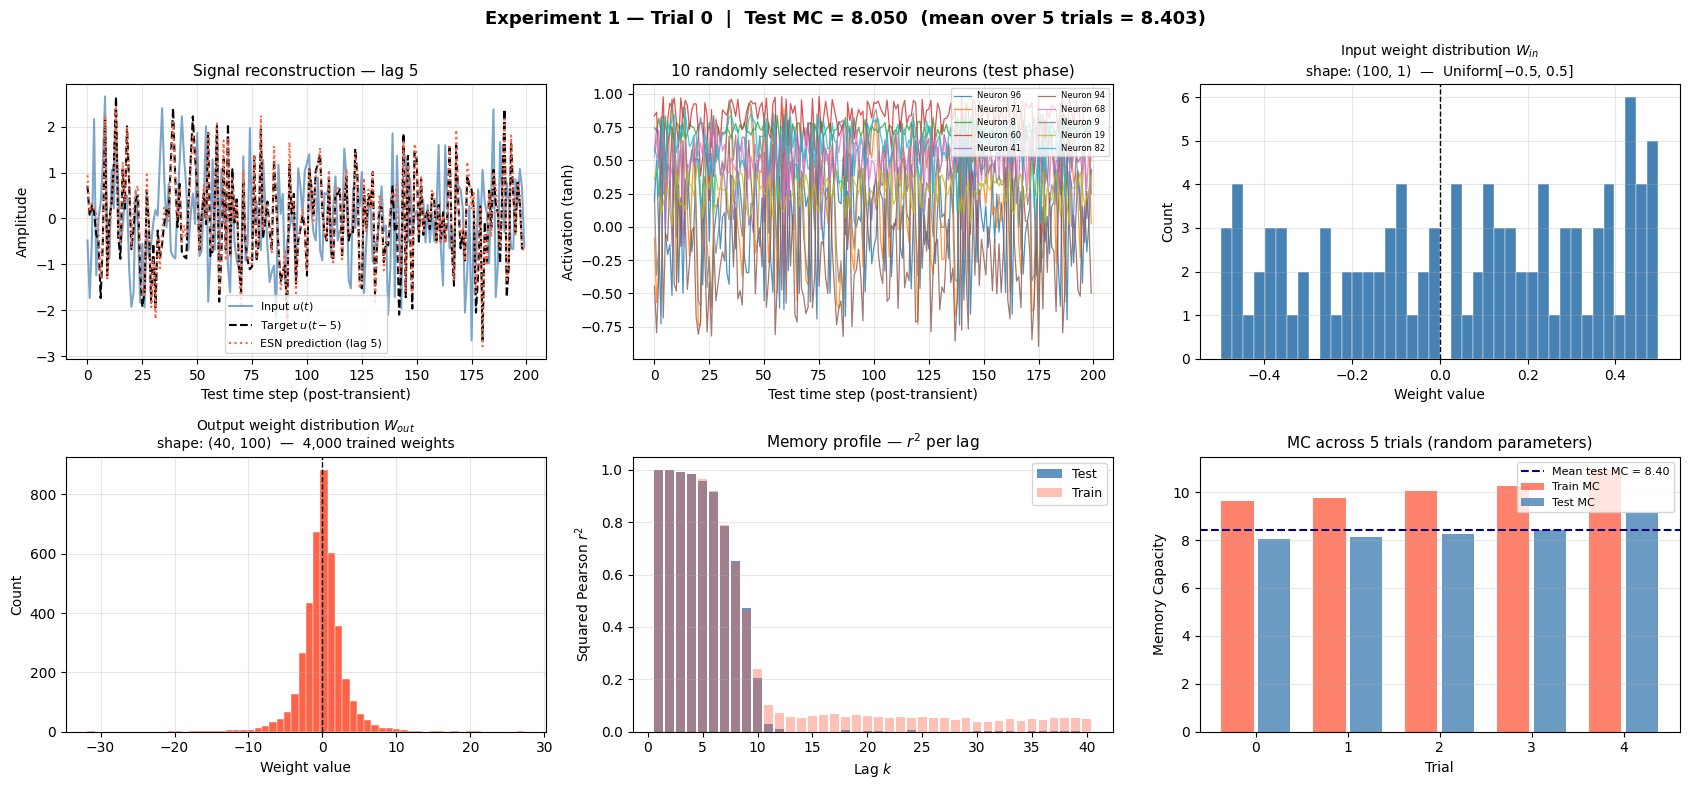

In [8]:
res  = results[PLOT_TRIAL]
esn  = res['esn']
t    = N_TRANSIENT   # already sliced in res, but kept for labels

# Randomly pick neuron indices to display (fixed seed for reproducibility)
neuron_idx = rng_global.choice(N_RESERVOIR, size=N_NEURONS_PLOT, replace=False)

# Time axis for the test window
time_axis = np.arange(PLOT_WINDOW)

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
fig.suptitle(
    f"Experiment 1 — Trial {PLOT_TRIAL}  |  "
    f"Test MC = {res['test_mc']:.3f}  (mean over {N_TRIALS} trials = {np.mean(test_mcs):.3f})",
    fontsize=13, fontweight='bold'
)

# ── Panel 1: Signal reconstruction at one lag
ax = axes[0, 0]
ax.plot(time_axis,
        res['X_test'][:PLOT_WINDOW, 0],
        color='steelblue', lw=1.5, alpha=0.7, label='Input $u(t)$')
ax.plot(time_axis,
        res['y_test'][:PLOT_WINDOW, PLOT_LAG - 1],
        color='black', lw=1.5, linestyle='--',
        label=f'Target $u(t-{PLOT_LAG})$')
ax.plot(time_axis,
        res['y_pred_test'][:PLOT_WINDOW, PLOT_LAG - 1],
        color='tomato', lw=1.5, linestyle=':',
        label=f'ESN prediction (lag {PLOT_LAG})')
ax.set_title(f'Signal reconstruction — lag {PLOT_LAG}', fontsize=11)
ax.set_xlabel('Test time step (post-transient)')
ax.set_ylabel('Amplitude')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Panel 2: Neuron traces
ax = axes[0, 1]
states_test = esn.states_pred_[N_TRANSIENT:]   # drop test transient
cmap = plt.cm.tab10
for i, nidx in enumerate(neuron_idx):
    ax.plot(time_axis,
            states_test[:PLOT_WINDOW, nidx],
            lw=0.9, alpha=0.8,
            color=cmap(i % 10),
            label=f'Neuron {nidx}')
ax.set_title(f'{N_NEURONS_PLOT} randomly selected reservoir neurons (test phase)', fontsize=11)
ax.set_xlabel('Test time step (post-transient)')
ax.set_ylabel('Activation (tanh)')
ax.legend(fontsize=6, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3)

# ── Panel 3: Input weight distribution W_in
# W_in has shape (N_RESERVOIR, 1): one weight per neuron, drawn uniformly
# from [-INPUT_SCALING, +INPUT_SCALING]. The histogram makes the uniform
# distribution explicit and invites comparison with W_out below.
ax = axes[0, 2]
ax.hist(res['W_in'].flatten(), bins=40, color='steelblue',
        edgecolor='white', linewidth=0.3)
ax.axvline(0, color='black', lw=1, linestyle='--')
ax.set_title('Input weight distribution $W_{in}$\n'
             f'shape: ({N_RESERVOIR}, 1)  —  Uniform[$-${INPUT_SCALING}, {INPUT_SCALING}]',
             fontsize=10)
ax.set_xlabel('Weight value')
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)

# ── Panel 4: Output weight distribution W_out
# W_out has shape (NUM_DELAYS, N_RESERVOIR): for each of the NUM_DELAYS
# output nodes, there is one learned weight per reservoir neuron.
# Flattening gives NUM_DELAYS × N_RESERVOIR values in total.
ax = axes[1, 0]
n_wout = esn.W_out_.shape[0] * esn.W_out_.shape[1]
ax.hist(esn.W_out_.flatten(), bins=60, color='tomato',
        edgecolor='white', linewidth=0.3)
ax.axvline(0, color='black', lw=1, linestyle='--')
ax.set_title('Output weight distribution $W_{out}$\n'
             f'shape: ({NUM_DELAYS}, {N_RESERVOIR})  —  {n_wout:,} trained weights',
             fontsize=10)
ax.set_xlabel('Weight value')
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)

# ── Panel 5: Memory profile — r² per lag ─────────────────────────────────
ax = axes[1, 1]
lags = np.arange(1, NUM_DELAYS + 1)
ax.bar(lags, res['test_r2'], color='steelblue', alpha=0.85, label='Test')
ax.bar(lags, res['train_r2'], color='tomato', alpha=0.4, label='Train')
ax.set_title('Memory profile — $r^2$ per lag', fontsize=11)
ax.set_xlabel('Lag $k$')
ax.set_ylabel('Squared Pearson $r^2$')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# ── Panel 6: Trial-by-trial MC summary ───────────────────────────────────
ax = axes[1, 2]
x = np.arange(N_TRIALS)
ax.bar(x - 0.2, train_mcs, width=0.35, color='tomato',   alpha=0.8, label='Train MC')
ax.bar(x + 0.2, test_mcs,  width=0.35, color='steelblue', alpha=0.8, label='Test MC')
ax.axhline(np.mean(test_mcs), color='navy', lw=1.5, linestyle='--',
           label=f'Mean test MC = {np.mean(test_mcs):.2f}')
ax.set_title(f'MC across {N_TRIALS} trials (random parameters)', fontsize=11)
ax.set_xlabel('Trial')
ax.set_ylabel('Memory Capacity')
ax.set_xticks(x)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/experiment_1_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Discussion questions

Think about the following before moving to Experiment 2:

1. **How does the test MC compare to the theoretical maximum?** What fraction of the theoretical bound did the untuned reservoir recover?

2. **Look at the neuron traces.** Can you identify neurons that seem to respond to recent inputs versus neurons that seem to carry slower, integrated signals? What does this tell you about the reservoir as a feature extractor?

3. **Look at the memory profile.** Does $r^2$ decay monotonically with lag, or are there irregularities? What would a perfect reservoir's profile look like?

4. **Look at the trial-by-trial MC.** How variable is performance across random seeds? What does this tell you about the reliability of a single-run evaluation?

5. **Train MC vs. Test MC.** Are they close? If train MC is substantially higher, what might be happening?

6. **What properties of $W_{in}$ and $W_{out}$ differ?** One is random and fixed; the other is trained. How does that asymmetry relate to the reservoir computing philosophy?